In [1]:
%load_ext autoreload
%autoreload 2

import functools
import gc
from math import pi
import os
from typing import Callable


os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'


import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import ArrayLike, NDArray
import scipy.optimize
import tqdm
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.dressed_control_fluxonium import (
    create_driven_fluxonium,
    calculate_avoided_crossing_gap,
    calculate_amplitude_for_deltap,
)
from fluxoniumcr.floquet import AdiabaticFloquetBasis
from fluxoniumcr.optimize import find_root, get_monotonic_increasing_intervals
from fluxoniumcr.qubits.fluxonium import Fluxonium
from fluxoniumcr.utils import load_arguments

In [2]:
parent_path = DATA_DIR/"charge_operator/EJ=4.00,EC=1.20,EL=0.40"
argm = load_arguments(parent_path)

dataset_path = parent_path/"amplitude_from_deltap.hdf5"

In [3]:
fx = Fluxonium(
    EJ=argm.EJ,
    EC=argm.EC,
    EL=argm.EL,
    dim=argm.dim,
    cutoff=argm.cutoff,
)
E = fx.eigenvalues
qubit_frequency = E[1] - E[0]
n_op = fx.get_operator('charge')
Ω0 = qubit_frequency/abs(n_op[0, 1])

lookup_amps = Ω0 * np.asarray(argm.lookup_amplitudes)
lookup_deg_tol = argm.lookup_degeneracy_tol
deg_tol = argm.degeneracy_tol

In [30]:
if dataset_path.exists():
    dataset = xr.load_dataset(dataset_path, engine='h5netcdf')
else:
    dataset = xr.Dataset(
        attrs=dict(
            EJ=argm.EJ,
            EC=argm.EC,
            EL=argm.EL,
            lookup_degeneracy_tolerance=lookup_deg_tol,
        )
    )

    frequency_coord = xr.DataArray(
        argm.frequencies,
        dims=['frequency'],
        attrs=dict(
            long_name="Drive frequency",
            units="Grad/s",
        )
    )

    deltap_coord = xr.DataArray(
        argm.delta_polarizations,
        dims=['deltap'],
        attrs=dict(
            long_name="Conditional polarization magnitude",
        )
    )

    dataset['amplitude'] = xr.DataArray(
        data=np.float64('nan'),
        coords=[frequency_coord, deltap_coord],
        attrs=dict(
            long_name="Drive amplitude",
            units="Grad/s",
            plot_unit=Ω0,
        )
    )
    
    dataset['amplitude_valid'] = xr.DataArray(
        data=False,
        coords=[frequency_coord, deltap_coord],
        attrs=dict(
            long_name="Valid amplitude flag",
        )
    )

In [167]:
for freq in tqdm.tqdm(dataset.frequency.data):
    ds = dataset.loc[dict(frequency=freq)]
    
    # Skip if we've already calculated the amplitudes for this drive frequency.
    if np.isfinite(ds.amplitude).any(): continue
    
    floquet_basis = create_driven_fluxonium(
        fx,
        freq,
        deg_tol=deg_tol,
        phase_gauge=True,
    )
    floquet_basis.generate_lookup(
        lookup_amps,
        deg_tol=lookup_deg_tol,
    )
        
    ds.amplitude[:] = calculate_amplitude_for_deltap(
        fx,
        floquet_basis,
        ds.deltap,
    )
    
    dataset.to_netcdf(dataset_path, engine='h5netcdf')
    
    gc.collect()

100%|█████████████████████████████████████████████████| 751/751 [00:13<00:00, 55.10it/s]


# Find avoided crossings encountered for each drive frequency

In [12]:
def find_crossings(
        floquet_basis,
        amplitudes,
):
    drive_freq = 2*pi/floquet_basis.T
    
    quasienergies = np.array([
        floquet_basis.quasienergies(amp)
        for amp in amplitudes
    ])
    
    crossings = {}
    for i in range(6):
        for j in range(i):
            delta = quasienergies[:, i] - quasienergies[:, j]
            k_data = 2*(delta//(2*drive_freq)).astype(int)
            indices = np.nonzero(np.diff(k_data))[0]
            for idx in indices:
                k = int(max(k_data[idx], k_data[idx+1]))
                
                if (i, j, k) in crossings:
                    # Earlier crossing already exists.
                    continue
                
                # Search +/- 5 MHz in amplitude away from crossing.
                x0 = max(
                    amplitudes[idx] - 5e-3 * 2*pi,
                    min(amplitudes),
                )
                x1 = min(
                    amplitudes[idx+1] + 5e-3 * 2*pi,
                    max(amplitudes),
                )
                
                amp, gap = calculate_avoided_crossing_gap(
                    floquet_basis,
                    i=i,
                    j=j,
                    k=k,
                    step_size=10e-3 * 2*pi,
                    xtol=1e-9,
                    x0=x0,
                    x1=x1,
                )
                if amp is None: continue
                crossings[(i, j, k)] = (amp, gap)
                
    return crossings


freq_data = []
ac_i_data = []
ac_j_data = []
ac_k_data = []
ac_amp_data = []
ac_gap_data = []

for freq in tqdm.tqdm(dataset.frequency.data):
    # Too many crossings at low frequency
    if freq < 0.5 * 2*np.pi: continue
    ds = dataset.loc[dict(frequency=freq)]
    
    floquet_basis = create_driven_fluxonium(
        fx,
        freq,
        phase_gauge=True,
        glide_reflection=True,
        time_reversal=True,
    )
    
    floquet_basis.generate_lookup(
        lookup_amps,
        deg_tol=lookup_deg_tol,
    )
    avoided_crossings = find_crossings(
        floquet_basis,
        np.linspace(0, 1.0) * Ω0,
    )

    for (i, j, k), (ac_amp, ac_gap) in avoided_crossings.items():
        if j > 1: continue
        freq_data.append(freq)
        ac_i_data.append(i)
        ac_j_data.append(j)
        ac_k_data.append(k)
        ac_amp_data.append(ac_amp)
        ac_gap_data.append(ac_gap)

100%|█████████████████████████████████████████████████| 751/751 [24:01<00:00,  1.92s/it]


In [13]:
transition_index_lookup = {}
harmonic_data = []
bra_data = []
ket_data = []
frequency_data = []
amplitude_data = []
gap_data = []
transition_index_data = []

for i, (bra, ket, harmonic) in enumerate(zip(
        ac_i_data,
        ac_j_data,
        ac_k_data,
)):
    key = int(bra), int(ket), int(harmonic)\
    
    if (bra + ket) % 2 == 1:
        if bra % 2 == 1:
            harmonic += 1
        else:
            harmonic -= 1
            
    if key not in transition_index_lookup:
        transition_index_lookup[key] = len(transition_index_lookup)
        harmonic_data.append(harmonic)
        bra_data.append(bra)
        ket_data.append(ket)
    tid = transition_index_lookup[key]
    frequency_data.append(freq_data[i])
    amplitude_data.append(ac_amp_data[i])
    gap_data.append(ac_gap_data[i])
    transition_index_data.append(tid)
    
for i in range(len(transition_index_lookup)):
    harmonic = harmonic_data[i]
    bra = bra_data[i]
    ket = ket_data[i]
    bare_freq = (E[bra] - E[ket])/harmonic
    frequency_data.append(bare_freq)
    amplitude_data.append(0)
    gap_data.append(0)
    transition_index_data.append(i)

In [14]:
# Save the data that we previously dumped into python lists into a dataset.

dataset_crossings = xr.Dataset()

dataset_crossings['frequency'] = xr.DataArray(
    frequency_data,
    dims=['dim_0'],
    attrs=dict(
        long_name="Drive frequency",
        units="Grad/s",
    ),
)
dataset_crossings['amplitude'] = xr.DataArray(
    amplitude_data,
    dims=['dim_0'],
    attrs=dict(
        long_name="Avoided crossing drive amplitude",
        units="Grad/s",
    ),
)
dataset_crossings['gap'] = xr.DataArray(
    gap_data,
    dims=['dim_0'],
    attrs=dict(
        long_name="Avoided crossing gap",
        units="Grad/s",
    ),
)
dataset_crossings['transition_index'] = xr.DataArray(
    transition_index_data,
    dims=['dim_0'],
    attrs=dict(
        instance_dimension='dim_1',
    ),
)

dataset_crossings['harmonic'] = xr.DataArray(
    harmonic_data,
    dims=['dim_1'],
    attrs=dict(
        long_name="Number of drive photons absorbed",
    ),
)
dataset_crossings['bra'] = xr.DataArray(
    bra_data,
    dims=['dim_1'],
    attrs=dict(
        long_name="Final state index",
    ),
)
dataset_crossings['ket'] = xr.DataArray(
    ket_data,
    dims=['dim_1'],
    attrs=dict(
        long_name="Initial state index",
    ),
)

dataset_crossings.to_netcdf(parent_path/"crossings.hdf5")

# Visualize the avoided crossings

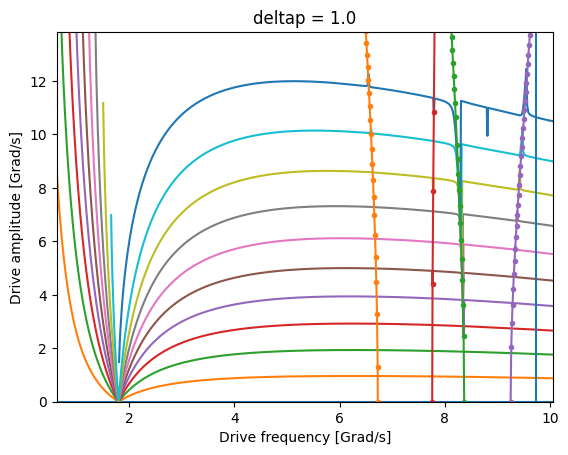

In [33]:
for deltap in dataset.deltap.data:
    dataset.sel(deltap=deltap).amplitude.plot()

for harmonic, bra, ket in [
    (4, 2, 0),
    (3, 2, 1),
    (5, 3, 0),
    (4, 3, 1),
]:
    tid = ((dataset3.harmonic == harmonic) & (dataset3.bra == bra) & (dataset3.ket == ket)).argmax().item()
    ds = dataset3.sel(dim_0=(dataset3.transition_index==tid))

    x_data = ds.frequency.data
    y_data = ds.amplitude.data
    idx = np.argsort(x_data)
    x_data = x_data[idx]
    y_data = y_data[idx]

    plt.plot(x_data, y_data, marker='.')
    
plt.xlim(0.1*2*np.pi, 1.6*2*np.pi)
plt.ylim(0, 1 * Ω0)
# plt.xlim(6, 10)
# plt.axvline(7.83)
plt.ylim(0, 0.61*Ω0)

plt.axvline(1.55*2*pi)

# Fit a spline to the contours that are away from the avoided crossings

In [102]:
for freq in tqdm.tqdm(dataset.frequency.data):
    for deltap in dataset.deltap.data:
        ds = dataset.loc[dict(frequency=freq, deltap=deltap)]
        amp = ds.amplitude.item()
        if np.isnan(amp): continue
        for transition_index, ac_ds in dataset3.groupby('transition_index'):
            idx = np.argsort(ac_ds.amplitude.data)
            freq_ac = np.interp(amp, ac_ds.amplitude.data[idx], ac_ds.frequency.data[idx])
            gap = np.interp(amp, ac_ds.amplitude.data[idx], ac_ds.gap.data[idx])
            num_photons = dataset3.sel(dim_1=transition_index).harmonic.item()
            delta = 20*gap/num_photons
            if abs(freq - freq_ac) < delta:
                ds.amplitude_valid[()] = False
                break
        else:
            ds.amplitude_valid[()] = True

100%|█████████████████████████████████████████████████| 751/751 [02:44<00:00,  4.56it/s]


In [179]:
dataset['amplitude_spline'] = dataset.amplitude.copy()

for deltap in dataset.deltap.data:
    ds = dataset.loc[dict(deltap=deltap)]
    ds_valid = ds.where(ds.amplitude_valid).dropna('frequency')

    x_data = ds_valid.frequency.data
    y_data = ds_valid.amplitude.data
    mask = x_data > 5
    x_data = x_data[mask]
    y_data = y_data[mask]

    w_data = np.ones_like(x_data)
    w_data[x_data < 6] = 1e3
    w_data[(8.7 < x_data) & (x_data < 9.1)] = 1e3
    w_data[(9.7 < x_data)] = 1e3
    spl = scipy.interpolate.make_smoothing_spline(
        x=x_data,
        y=y_data,
        w=w_data,
        lam=1.0,
    )
    
    ds_valid.amplitude_spline[mask] = spl(x_data)
    
    ds.amplitude_spline[:] = (
        xr.merge([ds_valid.amplitude_spline, ds.amplitude_spline], compat='override')\
        .amplitude_spline.interpolate_na('frequency', method='linear')
    )

(0.0, 15.867556615328562)

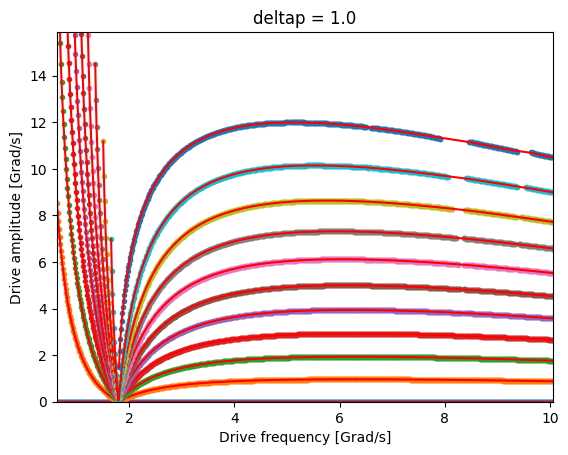

In [183]:
# Visualize the spline fits

for deltap, ds in dataset.groupby('deltap'):
    ds.where(ds.amplitude_valid).amplitude.plot(ls='', marker='.')
    ds.amplitude_spline.plot(c='red')   
    
plt.xlim(0.1*2*np.pi, 1.6*2*np.pi)
plt.ylim(0, 0.7 * Ω0)


In [184]:
dataset.to_netcdf(dataset_path)